In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_rows', 1000)

historical_pitches = pd.read_parquet('../../data/historical_pitches.parquet')


In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / 'src').exists():
    project_root = project_root.parent
if (project_root / 'src').exists():
    sys.path.insert(0, str(project_root))

from model_shared.db import get_read_cursor

outs = [
    'field_out', 'force_out', 'grounded_into_double_play',
    'sac_fly', 'sac_bunt', 'fielders_choice', 'double_play',
    'fielders_choice_out',
    'sac_fly_double_play', 'triple_play', 'popup', 'strikeout', 'strikeout_double_play'
]

strikeout_code = ['strikeout', 'strikeout_double_play']

whiff_code = ['swinging_strike', 'foul_tip', 'swinging_strike_blocked']

out_code = ['field_out', 'grounded_into_double_play', 'force_out', 'sac_bunt',
            'double_play', 'fielders_choice_out', 'sac_fly']

bip_code = ['hit_into_play']

hit_code = ['single', 'double', 'triple', 'home_run']

walk_code = ['walk', 'intent_walk', 'hit_by_pitch']

strike_code = ['swinging_strike', 'swinging_strike_blocked', 'called_strike',  'missed_bunt']

foul_code = ['foul', 'foul_bunt', 'foul_tip', 'bunt_foul_tip']

ball_code = ['ball', 'blocked_ball']

# building targets
def categorize_pitch(row):
    event = row['events']
    bb_type = row['bb_type']
    description = row['description']

    if event in strikeout_code:
        return 'strikeout'
    elif event in out_code:
        if bb_type == 'ground_ball':
            return 'groundout'
        elif bb_type in ['fly_ball', 'line_drive', 'popup']:
            return 'flyout'
    elif event in hit_code:
        return 'hit'
    elif event in walk_code:
        return 'walk'
    
    if description in strike_code:
        return 'strike'
    elif description in foul_code:
        return 'foul'
    elif description in ball_code:
        return 'ball'
    
    return 'other'
        

def get_historical_data(year=2024):
    query = """
        SELECT
            bb.player_id,
            bb.position,
            bb.ground_ball_percentage,
            bb.air_ball_percentage,
            pd.whiff_percentage,
            pd.chase_percentage,
            pd.zone_percentage,
            pd.zone_swing_percentage,
            pd.zone_contact_percentage,
            qoc.weak_percentage,
            qoc.under_percentage,
            qoc.topped_percentage,
            qoc.flareburner_percentage,
            qoc.solid_percentage,
            qoc.barrel_percentage,
            qoc.barrels_per_pa,
            pt.pitch_type,
            pt.pitch_count,
            pt.strikeouts,
            pt.batted_ball_events,
            pt.batting_average,
            pt.putaway_percentage,
            pt.whiff_percentage AS pitch_whiff_percentage,
            pt.launch_angle AS average_launch_angle,
            pt.exit_velocity AS average_exit_velocity,
            pt.expected_batting_average,
            pt.mph AS average_mph
        FROM batted_ball_profile bb 
        JOIN plate_discipline pd
            ON bb.player_id = pd.player_id
            AND bb.position = pd.position
            AND bb.year = pd.year
        JOIN quality_of_contact qoc
            ON bb.player_id = qoc.player_id
            AND bb.position = qoc.position
            AND bb.year = qoc.year
        JOIN pitch_tracking pt
            ON bb.player_id = pt.player_id
            AND bb.position = pt.position
            AND bb.year = pt.year
        WHERE bb.year = %s;
    """

    with get_read_cursor() as cursor:
        df = pd.read_sql(query, cursor.connection, params=(year,))
    return df

def df_process(df):
    df = df.sort_values(['game_date', 'game_pk', 'at_bat_number', 'pitch_number'])

    df['outcome'] = df.apply(categorize_pitch, axis=1)

    df['prev_pitch_type'] = df.groupby(['game_pk', 'at_bat_number'])['pitch_type'].shift(1)
    df['prev_pitch_type'] = df['prev_pitch_type'].fillna('NONE')

    df['runner_on_1b'] = df['on_1b'].notna().astype(int)
    df['runner_on_2b'] = df['on_2b'].notna().astype(int)
    df['runner_on_3b'] = df['on_3b'].notna().astype(int)

    return df

In [4]:
from model_shared.feature_engineering.location import (
    compute_bucket_boundaries, 
    add_location_targets,
    add_prev_location_features
)


def get_features(out_data, features):
    final_features = list(features)

    model_data = out_data[final_features]

    cat_cols = ['prev_pitch_type', 'pitch_type', 'stand', 'p_throws', 'inning_topbot']

    existing_cat_cols = [c for c in cat_cols if c in model_data.columns]
    model_data = pd.get_dummies(model_data, columns=existing_cat_cols, drop_first=True)
    return model_data

def get_zone_metrics(year=2024):
    query = """
        SELECT
            player_id,
            position,
            metric,
            zone1,
            zone2,
            zone3,
            zone4,
            zone5,
            zone6,
            zone7,
            zone8,
            zone9,
            zone11,
            zone12,
            zone13,
            zone14
        FROM zone_metrics
        WHERE year = %s
            AND metric IN ('batting_average', 'average_exit_velocity', 
                          'average_launch_angle', 'contact_batting_average',
                          'hard_hit_bip_percentage', 'expected_batting_average',
                          'strikeout_percentage', 'whiff_percentage', 'walk_percentage', 'ground_ball_percentage',
                          'line_drive_percentage', 'fly_ball_percentage', 'popup_percentage', 'swing_percentage'
                          )
    """
    with get_read_cursor() as cursor:
        df = pd.read_sql(query, cursor.connection, params=(year,))

    df_long = pd.melt(
        df, 
        id_vars=['player_id', 'position', 'metric'], 
        var_name='zone', 
        value_name='metric_value'
    )
    df_long['zone'] = df_long['zone'].str.replace('zone', '').astype(int)
    
    df_final = df_long.pivot_table(
        index=['player_id', 'position', 'zone'], 
        columns='metric', 
        values='metric_value'
    ).reset_index()
    
    return df_final


features = [
    # 'plate_x',
    # 'plate_z',
    'p_throws', 
    'stand', 
    'balls', 
    'pitch_type',
    'zone',
    # 'horiz_bucket',
    # 'vert_bucket',
    # 'in_zone',
    'strikes', 
    'runner_on_1b',
    'runner_on_2b', 
    'runner_on_3b', 
    'outs_when_up', 
    'inning',
    'bat_score',
    'fld_score',
    'inning_topbot',
    'sz_top',
    'sz_bot',
    'bb_type',
    'prev_pitch_type',
    'launch_speed', 'launch_angle',
    'batter_prev_whiff_rate', 
    'batter_prev_gb_rate', 'batter_prev_fb_rate', 'batter_prev_chase_rate', 
    'batter_prev_weak_rate', 'batter_prev_under_rate', 'batter_prev_topped_rate', 'batter_prev_flareburner_rate', 'batter_prev_solid_rate',
    'batter_prev_barrel_rate','batter_prev_barrels_per_pa',
    'batter_prev_looking_strike_rate',
    'batter_prev_zone_contact_rate',
    'pitcher_prev_fb_rate', 
    'pitcher_prev_gb_rate', 
    'pitcher_prev_whiff_rate', 
    'game_date', 'game_pk', 'pitch_number', 'description',
    'pitcher_prev_chase_rate',
    'pitcher_prev_weak_rate',
    'pitcher_prev_under_rate',
    'pitcher_prev_topped_rate',
    'pitcher_prev_flareburner_rate',
    'pitcher_prev_solid_rate',
    'pitcher_prev_barrel_rate',
    'pitcher_prev_barrels_per_pa',
    'outcome',
    'pitcher_pitch_putaway_rate',
    'batter_pitch_putaway_rate',
    'pitcher_pitch_whiff_rate',
    'batter_pitch_whiff_rate',
    'pitcher_pitch_average_launch_angle',
    'pitcher_pitch_average_exit_velocity',
    'pitcher_pitch_expected_batting_average',
    'batter_pitch_average_launch_angle',
    'batter_pitch_average_exit_velocity',
    'batter_pitch_expected_batting_average',
    'pitcher_pitch_batting_average',
    'batter_pitch_batting_average',
    'pitcher_zone_batting_average',
    'batter_zone_batting_average',
    'pitcher_zone_average_exit_velocity',
    'batter_zone_average_exit_velocity',
    'pitcher_zone_average_launch_angle',
    'batter_zone_average_launch_angle',
    'pitcher_zone_contact_batting_average',
    'batter_zone_contact_batting_average',
    'pitcher_zone_hard_hit_bip_percentage',
    'batter_zone_hard_hit_bip_percentage',
    'pitcher_zone_expected_batting_average',
    'batter_zone_expected_batting_average',
    'batter_zone_strikeout_percentage',
    'pitcher_zone_strikeout_percentage',
    'batter_zone_whiff_percentage',
    'pitcher_zone_whiff_percentage',
    'batter_zone_fly_ball_rate',
    'pitcher_zone_fly_ball_rate',
    'batter_zone_walk_percentage',
    'pitcher_zone_walk_percentage',
    'batter_zone_ground_ball_percentage',
    'pitcher_zone_ground_ball_percentage',
    'batter_zone_swing_percentage',
    'pitcher_zone_swing_percentage',
    'pitcher_pitch_average_mph',
    'batter_pitch_average_mph'
]


def build_season_features(current_pitch_data, historical_year):
    historical_df = get_historical_data(historical_year)
    zone_metrics_df = get_zone_metrics(historical_year)

    prev_cols = [
        'player_id', 'position', 'ground_ball_percentage', 'air_ball_percentage',
        'whiff_percentage', 'chase_percentage', 'weak_percentage', 
        'under_percentage', 'topped_percentage', 'zone_contact_percentage',
        'zone_percentage', 'zone_swing_percentage', 'flareburner_percentage', 'solid_percentage', 'barrel_percentage', 'barrels_per_pa'
    ]

    batter_baselines = historical_df[historical_df['position'] == 'B'][prev_cols].drop_duplicates().add_prefix('batter_prev_')
    pitcher_baselines = historical_df[historical_df['position'] == 'P'][prev_cols].drop_duplicates().add_prefix('pitcher_prev_')

    pitch_data = current_pitch_data.merge(batter_baselines, left_on='batter', right_on='batter_prev_player_id', how='left')
    pitch_data = pitch_data.merge(pitcher_baselines, left_on='pitcher', right_on='pitcher_prev_player_id', how='left')

    pt_cols = [
        'player_id', 'position', 'pitch_type', 'pitch_count', 'strikeouts', 'batted_ball_events',
        'batting_average', 'putaway_percentage', 'pitch_whiff_percentage', 'average_launch_angle', 'average_exit_velocity', 'expected_batting_average',
        'average_mph'
    ]

    batter_pt = historical_df[historical_df['position'] == 'B'][pt_cols].drop_duplicates().add_prefix('batter_pitch_')
    pitcher_pt = historical_df[historical_df['position'] == 'P'][pt_cols].drop_duplicates().add_prefix('pitcher_pitch_')

    pitch_data = pitch_data.merge(batter_pt, left_on=['batter', 'pitch_type'], right_on=['batter_pitch_player_id', 'batter_pitch_pitch_type'], how='left')
    pitch_data = pitch_data.merge(pitcher_pt, left_on=['pitcher', 'pitch_type'], right_on=['pitcher_pitch_player_id', 'pitcher_pitch_pitch_type'], how='left')

    batter_zone = zone_metrics_df[zone_metrics_df['position'] == 'B'].add_prefix('batter_zone_')
    pitcher_zone = zone_metrics_df[zone_metrics_df['position'] == 'P'].add_prefix('pitcher_zone_')

    pitch_data = pitch_data.merge(batter_zone, left_on=['batter', 'zone'], right_on=['batter_zone_player_id', 'batter_zone_zone'], how='left')
    pitch_data = pitch_data.merge(pitcher_zone, left_on=['pitcher', 'zone'], right_on=['pitcher_zone_player_id', 'pitcher_zone_zone'], how='left')

    pitch_data = pitch_data.rename(columns={
        'batter_prev_ground_ball_percentage': 'batter_prev_gb_rate', 
        'batter_prev_air_ball_percentage': 'batter_prev_fb_rate',
        'batter_prev_whiff_percentage': 'batter_prev_whiff_rate',
        'batter_prev_chase_percentage': 'batter_prev_chase_rate',
        'batter_prev_weak_percentage': 'batter_prev_weak_rate',
        'batter_prev_under_percentage': 'batter_prev_under_rate',
        'batter_prev_topped_percentage': 'batter_prev_topped_rate',
        'batter_prev_flareburner_percentage': 'batter_prev_flareburner_rate',
        'batter_prev_solid_percentage': 'batter_prev_solid_rate',
        'batter_prev_barrel_percentage': 'batter_prev_barrel_rate',
        'batter_prev_barrels_per_pa': 'batter_prev_barrels_per_pa',
        'batter_prev_zone_contact_percentage': 'batter_prev_zone_contact_rate',
        'batter_pitch_putaway_percentage': 'batter_pitch_putaway_rate',
        'batter_pitch_pitch_whiff_percentage': 'batter_pitch_whiff_rate',
        'pitcher_prev_ground_ball_percentage': 'pitcher_prev_gb_rate', 
        'pitcher_prev_air_ball_percentage': 'pitcher_prev_fb_rate',
        'pitcher_prev_whiff_percentage': 'pitcher_prev_whiff_rate',
        'pitcher_prev_chase_percentage': 'pitcher_prev_chase_rate',
        'pitcher_prev_weak_percentage': 'pitcher_prev_weak_rate',
        'pitcher_prev_under_percentage': 'pitcher_prev_under_rate',
        'pitcher_prev_topped_percentage': 'pitcher_prev_topped_rate',
        'pitcher_prev_flareburner_percentage': 'pitcher_prev_flareburner_rate',
        'pitcher_prev_solid_percentage': 'pitcher_prev_solid_rate',
        'pitcher_prev_barrel_percentage': 'pitcher_prev_barrel_rate',
        'pitcher_prev_barrels_per_pa': 'pitcher_prev_barrels_per_pa',
        'pitcher_pitch_putaway_percentage': 'pitcher_pitch_putaway_rate',
        'pitcher_pitch_pitch_whiff_percentage': 'pitcher_pitch_whiff_rate',
    })

    pitch_data['batter_prev_looking_strike_rate'] = pitch_data['batter_prev_zone_percentage'] * (1 - pitch_data['batter_prev_zone_swing_percentage'] / 100.0)
    pitch_data['batter_zone_fly_ball_rate'] = pitch_data['batter_zone_line_drive_percentage'] + pitch_data['batter_zone_fly_ball_percentage'] + pitch_data['batter_zone_popup_percentage']
    pitch_data['pitcher_zone_fly_ball_rate'] = pitch_data['pitcher_zone_line_drive_percentage'] + pitch_data['pitcher_zone_fly_ball_percentage'] + pitch_data['pitcher_zone_popup_percentage']

    pitch_data = pitch_data.drop(columns=[
        'batter_prev_zone_swing_percentage',
        'batter_prev_zone_percentage', 
        'pitcher_prev_zone_swing_percentage',
        'pitcher_prev_zone_percentage',
        'pitcher_prev_zone_contact_percentage',
    ])

    sql_pct_cols = [
        'batter_prev_fb_rate', 'batter_prev_gb_rate', 'batter_prev_whiff_rate',
        'batter_prev_chase_rate', 'batter_prev_weak_rate', 'batter_prev_under_rate',
        'batter_prev_topped_rate', 'batter_prev_flareburner_rate', 'batter_prev_solid_rate', 'batter_prev_barrel_rate', 
        'batter_prev_barrels_per_pa', 'batter_prev_looking_strike_rate',
        'batter_prev_zone_contact_rate', 'batter_pitch_putaway_rate',
        'batter_pitch_whiff_rate', 'pitcher_prev_fb_rate', 'pitcher_prev_gb_rate',
        'pitcher_prev_whiff_rate', 'pitcher_prev_chase_rate', 'pitcher_prev_weak_rate',
        'pitcher_prev_under_rate', 'pitcher_prev_topped_rate', 'pitcher_prev_flareburner_rate', 'pitcher_prev_solid_rate', 'pitcher_prev_barrel_rate', 
        'pitcher_prev_barrels_per_pa', 'pitcher_pitch_putaway_rate', 'pitcher_pitch_whiff_rate'
    ]

    for col in sql_pct_cols:
        if col in pitch_data.columns:
            pitch_data[col] = pitch_data[col] / 100.0
            
    return pitch_data


# df_25 = df_process(data25)
# df_24 = df_process(data24)
# df_23 = df_process(data23)
# df_22 = df_process(data22)
# df_21 = df_process(data21)
# df_20 = df_process(data20)
# df_19 = df_process(data19)
# df_18 = df_process(data18)
# df_17 = df_process(data17)
# df_16 = df_process(data16)
# pitch_data = []

# boundary_data = historical_pitches.copy()
# boundaries = compute_bucket_boundaries(boundary_data)
# historical_pitches = add_location_targets(historical_pitches, boundaries)
# historical_pitches = df_process(historical_pitches)

pitch_data = []

for data_year, hist_year in [
    (2016, 2015),
    (2017, 2016),
    (2018, 2017),
    (2019, 2018),
    (2020, 2019),
    (2021, 2020),
    (2022, 2021),
    (2023, 2022),
    (2024, 2023),
    (2025, 2024),
]:
    print(f"Building {data_year} features...")
    df = historical_pitches[historical_pitches['game_year'] == data_year].copy()
    df = df_process(df)
    tmp = build_season_features(df, historical_year=hist_year)
    pitch_data.append(tmp)

pitch_data = pd.concat(pitch_data, ignore_index=True)

print("Total combined rows:", len(pitch_data))

model_data = get_features(pitch_data, features)
# model_data['zone_bucket'] = model_data['horiz_bucket'] * 3 + model_data['vert_bucket']


Building 2016 features...


C:\Users\Lucas\AppData\Local\Temp\ipykernel_12120\2627223155.py:112: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_12120\1325737677.py:48: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Building 2017 features...


C:\Users\Lucas\AppData\Local\Temp\ipykernel_12120\2627223155.py:112: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_12120\1325737677.py:48: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Building 2018 features...


...

Building 2024 features...


C:\Users\Lucas\AppData\Local\Temp\ipykernel_12120\2627223155.py:112: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_12120\1325737677.py:48: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Building 2025 features...


C:\Users\Lucas\AppData\Local\Temp\ipykernel_12120\2627223155.py:112: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_12120\1325737677.py:48: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Total combined rows: 6816605


In [5]:
from matplotlib import pyplot as plt
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.frozen import FrozenEstimator
from sklearn.utils import compute_sample_weight
import xgboost as xgb
import pandas as pd
from sklearn.metrics import log_loss, brier_score_loss
import joblib

bip_labels = {
    'fly_ball': 0,
    'line_drive': 0,
    'popup': 0,
    'ground_ball': 1,
}

model_data['is_hard_hit'] = (
    (model_data['launch_speed'] * 1.5 - model_data['launch_angle'] >= 117) &
    (model_data['launch_speed'] + model_data['launch_angle'] >= 124) &
    (model_data['launch_speed'] >= 98) &
    (model_data['launch_angle'].between(4, 50))
).fillna(False).astype(int)



model_data['target1'] = model_data['outcome'].isin(['strikeout', 'groundout', 'flyout', 'hit']).astype(int)
model_data['target2'] = (model_data['outcome'] == 'strikeout').astype(int)
model_data['target3'] = model_data['bb_type'].map(bip_labels).fillna(-1).astype(int)
model_data['target4'] = model_data['is_hard_hit'].astype(int)

model_data['two_strikes'] = (model_data['strikes'] == 2).astype(int)
model_data['full_count'] = ((model_data['balls'] == 3) & (model_data['strikes'] == 2)).astype(int)
model_data['is_platoon'] = model_data['p_throws_R'] != model_data['stand_R']

features = [col for col in model_data.columns if col not in [
    'target1', 'target2', 'target3', 'target4', 'is_hard_hit', 
    'launch_angle', 'launch_speed', 'outcome', 'game_date', 'game_pk',
     'pitch_number', 'bb_type', 'description'
]]
model_data = model_data.sort_values(['game_date', 'game_pk', 'pitch_number'])

length = len(model_data)
train_end = int(length * 0.7)
val_end = int(length * 0.85)

train_data = model_data.iloc[:train_end]
val_data = model_data.iloc[train_end:val_end]
test_data = model_data.iloc[val_end:]

### Stage 1: Predict PA End vs Non-PA End, excluding walks

[0]	validation_0-logloss:0.67086
[100]	validation_0-logloss:0.53373
[200]	validation_0-logloss:0.52977
[300]	validation_0-logloss:0.52722
[400]	validation_0-logloss:0.52491
[500]	validation_0-logloss:0.52349
[600]	validation_0-logloss:0.52259
[700]	validation_0-logloss:0.52120
[800]	validation_0-logloss:0.52039
[900]	validation_0-logloss:0.51925
[1000]	validation_0-logloss:0.51825
[1100]	validation_0-logloss:0.51742
[1200]	validation_0-logloss:0.51664
[1300]	validation_0-logloss:0.51597
[1400]	validation_0-logloss:0.51553
[1499]	validation_0-logloss:0.51540
two_strikes                               0.282862
zone                                      0.154842
strikes                                   0.114194
prev_pitch_type_NONE                      0.026469
pitch_type_SI                             0.023133
balls                                     0.023130
pitch_type_FF                             0.021046
batter_zone_swing_percentage              0.018917
pitch_type_CH               

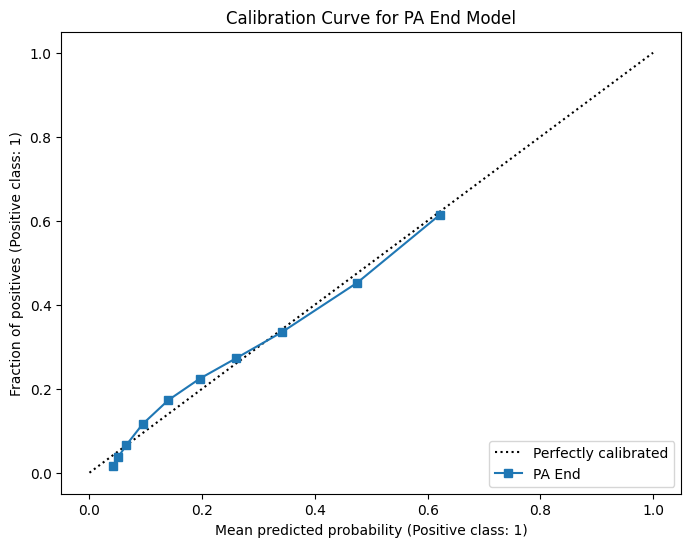

Probability metrics:
Log Loss: 0.44273
Brier Score: 0.14378
Distribution Check:
Real PA End Rate: 0.2308
Predicted Avg Prob: 0.2287
Simulated PA End Rate: 0.2287


In [6]:
X1_train = train_data[features]
y1_train = train_data['target1']

X1_val = val_data[features]
y1_val = val_data['target1']

X1_test = test_data[features]
y1_test = test_data['target1']

weights = compute_sample_weight(class_weight='balanced', y=y1_train)


xgb_out = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=-1,
    max_depth=6,
    n_estimators=1500,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=42
)

xgb_out.fit(X1_train, y1_train, eval_set=[(X1_val, y1_val)], verbose=100, sample_weight=weights)

calibrated_out = CalibratedClassifierCV(FrozenEstimator(xgb_out), method='sigmoid')
calibrated_out.fit(X1_val, y1_val)

y1_proba = calibrated_out.predict_proba(X1_test)[:, 1]

joblib.dump({
    'model': calibrated_out,
    'features': features
}, 'models/pa_end_model_v1.pkl')

importance = pd.Series(
    xgb_out.feature_importances_,
    index=X1_train.columns
).sort_values(ascending=False)
print(importance)

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y1_test == 1).astype(int),
    y1_proba,
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='PA End'
)
plt.title('Calibration Curve for PA End Model')
plt.show()

ll = log_loss(y1_test, y1_proba)
brier_score = brier_score_loss(y1_test, y1_proba)

print('Probability metrics:')
print(f'Log Loss: {ll:.5f}')
print(f'Brier Score: {brier_score:.5f}')

simulated_pa_ends = (np.random.rand(len(y1_proba)) < y1_proba).astype(int)

real_rate = y1_test.mean()
pred_rate = y1_proba.mean()
sim_rate = simulated_pa_ends.mean()

print("Distribution Check:")
print(f"Real PA End Rate: {real_rate:.4f}")
print(f"Predicted Avg Prob: {pred_rate:.4f}")
print(f"Simulated PA End Rate: {sim_rate:.4f}")

In [7]:
import pandas as pd
from sklearn.metrics import log_loss, brier_score_loss

results_df = X1_test.copy()
results_df['actual'] = y1_test.values
results_df['predicted_proba'] = y1_proba

results_df['is_two_strikes'] = results_df['strikes'] == 2

def get_metrics(df):
    if len(df) == 0: return None
    return pd.Series({
        'Log Loss': log_loss(df['actual'], df['predicted_proba']),
        'Brier Score': brier_score_loss(df['actual'], df['predicted_proba']),
        'Count': len(df),
        'Actual Rate': df['actual'].mean(),
        'Avg Pred Prob': df['predicted_proba'].mean()
    })

comparison = results_df.groupby('is_two_strikes').apply(get_metrics)
print("Comparison: Early Count vs. Two-Strike Count")
print(comparison)

results_df['count_string'] = results_df['balls'].astype(str) + "-" + results_df['strikes'].astype(str)
count_report = results_df.groupby('count_string').apply(get_metrics).sort_values('Log Loss')

print("\nGranular Count Report:")
print(count_report)

C:\Users\Lucas\AppData\Local\Temp\ipykernel_12120\1226195352.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  comparison = results_df.groupby('is_two_strikes').apply(get_metrics)


Comparison: Early Count vs. Two-Strike Count
                Log Loss  Brier Score     Count  Actual Rate  Avg Pred Prob
is_two_strikes                                                             
False           0.370103     0.114759  714449.0     0.154073       0.152481
True            0.611164     0.211083  308042.0     0.408782       0.405603

Granular Count Report:
              Log Loss  Brier Score     Count  Actual Rate  Avg Pred Prob
count_string                                                             
3-0           0.157088     0.035955   10165.0     0.037678       0.068970
0-0           0.314352     0.092784  262634.0     0.113900       0.112468
1-0           0.380601     0.118630   98603.0     0.156405       0.153268
2-0           0.383687     0.119987   33043.0     0.158581       0.163144
0-1           0.390254     0.122731  133238.0     0.170837       0.168234
4-2           0.393138     0.111458       2.0     0.500000       0.395187
1-1           0.427796     0.137239

C:\Users\Lucas\AppData\Local\Temp\ipykernel_12120\1226195352.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  count_report = results_df.groupby('count_string').apply(get_metrics).sort_values('Log Loss')


### Stage 2: Of PA Ends, predict Strikeout vs Non-Strikeout 

[0]	validation_0-logloss:0.52819
[100]	validation_0-logloss:0.33172
[200]	validation_0-logloss:0.32933
[300]	validation_0-logloss:0.32885
[400]	validation_0-logloss:0.32871
[415]	validation_0-logloss:0.32872
strikes                                   0.486285
two_strikes                               0.402713
prev_pitch_type_NONE                      0.055172
batter_zone_whiff_percentage              0.005927
zone                                      0.004065
batter_zone_strikeout_percentage          0.002976
pitcher_zone_whiff_percentage             0.001690
pitch_type_FF                             0.001622
pitcher_zone_strikeout_percentage         0.001205
batter_prev_whiff_rate                    0.001163
pitch_type_CH                             0.001128
is_platoon                                0.001086
full_count                                0.001063
balls                                     0.001013
pitch_type_SI                             0.000910
sz_bot                     

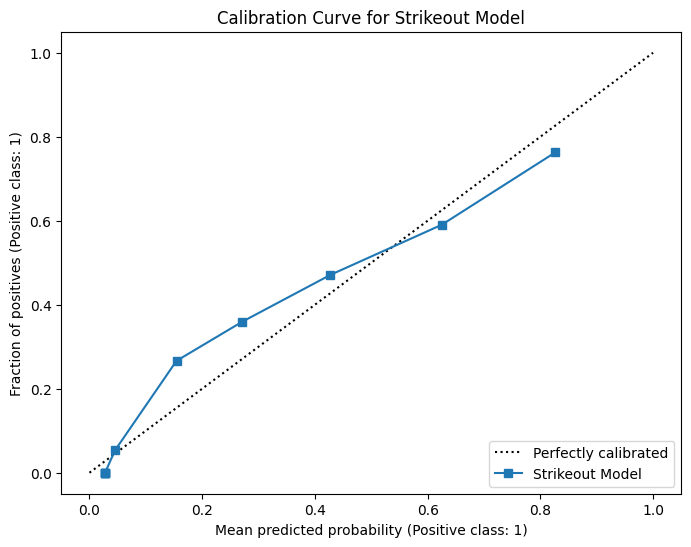

Probability metrics:
Log Loss: 0.34963
Brier Score: 0.11679
Distribution Check:
Real SO Rate: 0.2503
Predicted Avg Prob: 0.2461
Simulated SO Rate: 0.2453


In [8]:
train_data_s2 = train_data[train_data['target1'] == 1]
val_data_s2 = val_data[val_data['target1'] == 1]
test_data_s2 = test_data[test_data['target1'] == 1]

X2_train = train_data_s2[features]
y2_train = train_data_s2['target2']

X2_val = val_data_s2[features]
y2_val = val_data_s2['target2']

X2_test = test_data_s2[features]
y2_test = test_data_s2['target2']

xgb_so = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=-1,
    max_depth=6,
    n_estimators=1500,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=42
)

xgb_so.fit(X2_train, y2_train, eval_set=[(X2_val, y2_val)], verbose=100)

calibrated_so = CalibratedClassifierCV(FrozenEstimator(xgb_so), method='sigmoid')
calibrated_so.fit(X2_val, y2_val)

y2_proba = calibrated_so.predict_proba(X2_test)[:, 1]

joblib.dump({
    'model': calibrated_so,
    'features': features
}, 'models/so_model_v1.pkl')

importance = pd.Series(
    xgb_so.feature_importances_,
    index=X2_train.columns
).sort_values(ascending=False)
print(importance)

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y2_test == 1).astype(int),
    y2_proba,
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='Strikeout Model'
)
plt.title('Calibration Curve for Strikeout Model')
plt.show()

ll = log_loss(y2_test, y2_proba)
brier_score = brier_score_loss(y2_test, y2_proba)

print('Probability metrics:')
print(f'Log Loss: {ll:.5f}')
print(f'Brier Score: {brier_score:.5f}')

simulated_strikeouts = (np.random.rand(len(y2_proba)) < y2_proba).astype(int)

real_rate = y2_test.mean()
pred_rate = y2_proba.mean()
sim_rate = simulated_strikeouts.mean()

print("Distribution Check:")
print(f"Real SO Rate: {real_rate:.4f}")
print(f"Predicted Avg Prob: {pred_rate:.4f}")
print(f"Simulated SO Rate: {sim_rate:.4f}")

### Stage 3: Of Balls in Play, predict Groundball vs Flyball

[0]	validation_0-logloss:0.68070
[100]	validation_0-logloss:0.64666
[200]	validation_0-logloss:0.64344
[300]	validation_0-logloss:0.64236
[400]	validation_0-logloss:0.64189
[500]	validation_0-logloss:0.64157
[600]	validation_0-logloss:0.64135
[700]	validation_0-logloss:0.64120
[800]	validation_0-logloss:0.64103
[900]	validation_0-logloss:0.64092
[1000]	validation_0-logloss:0.64081
[1100]	validation_0-logloss:0.64072
[1200]	validation_0-logloss:0.64066
[1273]	validation_0-logloss:0.64063
zone                                      0.100710
pitch_type_FF                             0.051552
pitcher_pitch_average_launch_angle        0.050842
batter_pitch_average_launch_angle         0.046272
batter_zone_average_launch_angle          0.045588
pitch_type_SI                             0.044058
is_platoon                                0.028087
batter_prev_fb_rate                       0.016302
batter_zone_ground_ball_percentage        0.016089
pitch_type_ST                             0.01545

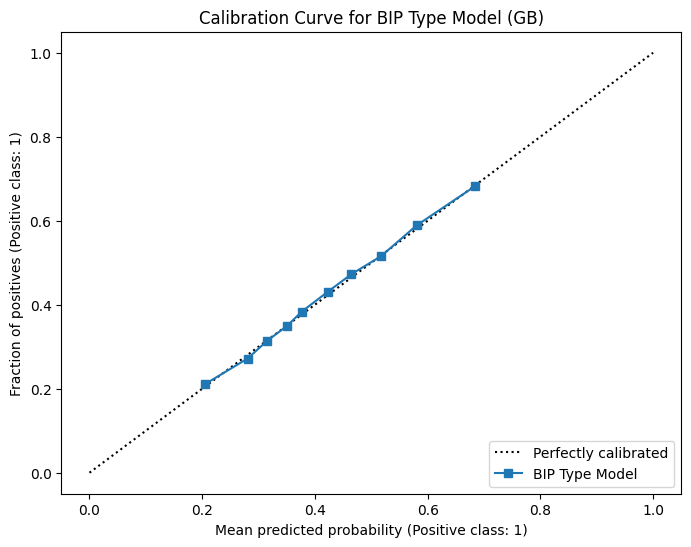

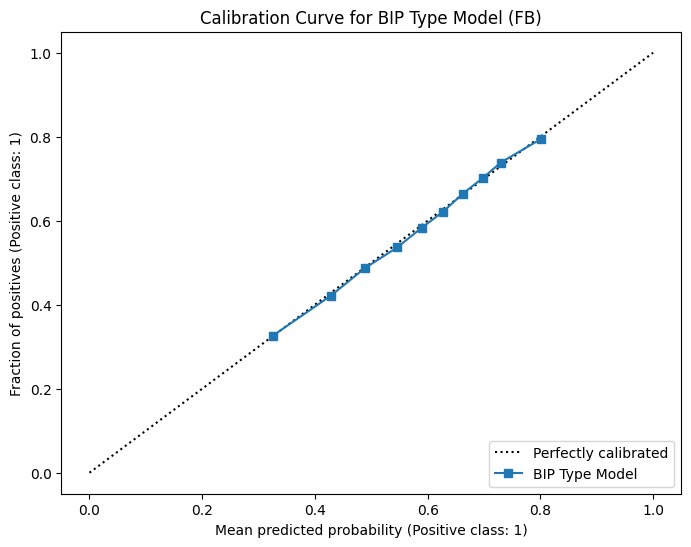

Probability metrics:
Log Loss: 0.63839
Brier Score: 0.22362
Distribution Check:
Real GB Rate: 0.4180
Predicted Avg Prob: 0.4159
Simulated GB Rate: 0.4166


In [9]:
train_data_s3 = train_data[(train_data['target1'] == 1) & (train_data['target2'] == 0)]
val_data_s3 = val_data[(val_data['target1'] == 1) & (val_data['target2'] == 0)]
test_data_s3 = test_data[(test_data['target1'] == 1) & (test_data['target2'] == 0)]

X3_train = train_data_s3[features]
y3_train = train_data_s3['target3']

X3_val = val_data_s3[features]
y3_val = val_data_s3['target3']

X3_test = test_data_s3[features]
y3_test = test_data_s3['target3']

xgb_bip = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=-1,
    max_depth=6,
    n_estimators=2000,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    min_child_weight=10,
    gamma=0.1,
    early_stopping_rounds=50
)

xgb_bip.fit(X3_train, y3_train, eval_set=[(X3_val, y3_val)], verbose=100)

calibrated_bip = CalibratedClassifierCV(FrozenEstimator(xgb_bip), method='isotonic')
calibrated_bip.fit(X3_val, y3_val)

y3_proba = calibrated_bip.predict_proba(X3_test)[:, 1]

joblib.dump({
    'model': calibrated_bip,
    'features': features
}, 'models/bip_model_v1.pkl')


importance = pd.Series(
    xgb_bip.feature_importances_,
    index=X3_train.columns
).sort_values(ascending=False)
print(importance)

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y3_test == 1).astype(int),
    y3_proba,
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='BIP Type Model'
)
plt.title('Calibration Curve for BIP Type Model (GB)')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y3_test == 0).astype(int),
    1 - y3_proba,
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='BIP Type Model'
)
plt.title('Calibration Curve for BIP Type Model (FB)')
plt.show()

ll = log_loss(y3_test, y3_proba)
brier_score = brier_score_loss(y3_test, y3_proba)

print('Probability metrics:')
print(f'Log Loss: {ll:.5f}')
print(f'Brier Score: {brier_score:.5f}')

simulated_bip = (np.random.rand(len(y3_proba)) < y3_proba).astype(int)

real_rate = y3_test.mean()
pred_rate = y3_proba.mean()
sim_rate = simulated_bip.mean()

print("Distribution Check:")
print(f"Real GB Rate: {real_rate:.4f}")
print(f"Predicted Avg Prob: {pred_rate:.4f}")
print(f"Simulated GB Rate: {sim_rate:.4f}")

### Stage 4: Of Flyballs, Predict Hard-Hit vs Not

[0]	validation_0-logloss:0.39148
[100]	validation_0-logloss:0.36912
[200]	validation_0-logloss:0.36693
[300]	validation_0-logloss:0.36613
[400]	validation_0-logloss:0.36589
[500]	validation_0-logloss:0.36577
[600]	validation_0-logloss:0.36565
[700]	validation_0-logloss:0.36551
[795]	validation_0-logloss:0.36549
batter_zone_average_exit_velocity         0.063097
batter_prev_barrel_rate                   0.060987
batter_zone_hard_hit_bip_percentage       0.058903
zone                                      0.038422
two_strikes                               0.027283
strikes                                   0.020949
batter_prev_barrels_per_pa                0.018027
batter_prev_whiff_rate                    0.017247
balls                                     0.016663
full_count                                0.016189
stand_R                                   0.014222
pitch_type_FF                             0.013624
batter_zone_swing_percentage              0.013119
pitch_type_SI           

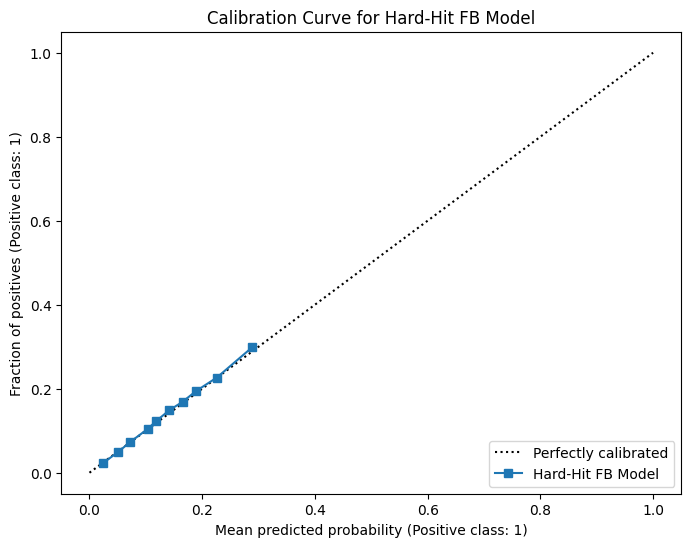

Probability metrics:
Log Loss: 0.37267
Brier Score: 0.11224
Distribution Check:
Real Hard-Hit FB Rate: 0.1374
Predicted Avg Prob: 0.1345
Simulated Hard-Hit FB Rate: 0.1341


In [10]:
train_data_s4 = train_data[(train_data['target1'] == 1) & (train_data['target2'] == 0) & (train_data['target3'] == 0)]
val_data_s4 = val_data[(val_data['target1'] == 1) & (val_data['target2'] == 0) & (val_data['target3'] == 0)]
test_data_s4 = test_data[(test_data['target1'] == 1) & (test_data['target2'] == 0) & (test_data['target3'] == 0)]

X4_train = train_data_s4[features]
y4_train = train_data_s4['target4']

X4_val = val_data_s4[features]
y4_val = val_data_s4['target4']

X4_test = test_data_s4[features]
y4_test = test_data_s4['target4']

xgb_fb = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=-1,
    max_depth=6,
    n_estimators=2000,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    min_child_weight=10,
    gamma=0.1,
    early_stopping_rounds=50
)

xgb_fb.fit(X4_train, y4_train, eval_set=[(X4_val, y4_val)], verbose=100)

calibrated_fb = CalibratedClassifierCV(FrozenEstimator(xgb_fb), method='isotonic')
calibrated_fb.fit(X4_val, y4_val)

y4_proba = calibrated_fb.predict_proba(X4_test)[:, 1]

joblib.dump({
    'model': calibrated_fb,
    'features': features
}, 'models/fb_model_v1.pkl')


importance = pd.Series(
    xgb_fb.feature_importances_,
    index=X4_train.columns
).sort_values(ascending=False)
print(importance)

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y4_test == 1).astype(int),
    y4_proba,
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='Hard-Hit FB Model'
)
plt.title('Calibration Curve for Hard-Hit FB Model')
plt.show()

ll = log_loss(y4_test, y4_proba)
brier_score = brier_score_loss(y4_test, y4_proba)

print('Probability metrics:')
print(f'Log Loss: {ll:.5f}')
print(f'Brier Score: {brier_score:.5f}')

simulated_bip = (np.random.rand(len(y4_proba)) < y4_proba).astype(int)

real_rate = y4_test.mean()
pred_rate = y4_proba.mean()
sim_rate = simulated_bip.mean()

print("Distribution Check:")
print(f"Real Hard-Hit FB Rate: {real_rate:.4f}")
print(f"Predicted Avg Prob: {pred_rate:.4f}")
print(f"Simulated Hard-Hit FB Rate: {sim_rate:.4f}")

### Combine previous models to generate probabilities for out types

In [11]:
def get_pitch_probabilities(X_full, xgb_pa, xgb_so, xgb_bb, X3_columns):
    p_pa_end = xgb_pa.predict_proba(X_full)[:, 1]
    p_no_end = 1.0 - p_pa_end

    p_so_given_end = xgb_so.predict_proba(X_full)[:, 1]

    X_for_stage3 = X_full.reindex(columns=X3_columns, fill_value=0.0)
    stage3_probs = xgb_bb.predict_proba(X_for_stage3)
    p_fb_given_non_so_end = stage3_probs[:, 0]
    p_gb_given_non_so_end = stage3_probs[:, 1]

    p_so = p_pa_end * p_so_given_end
    p_non_so_end = p_pa_end * (1.0 - p_so_given_end)

    p_go = p_non_so_end * p_gb_given_non_so_end
    p_fb = p_non_so_end * p_fb_given_non_so_end
    
    p_hhfb_given_fb = xgb_fb.predict_proba(X_full)[:, 1]

    p_hhfb = p_fb * p_hhfb_given_fb
    p_fo = p_fb * (1.0 - p_hhfb_given_fb)

    out = pd.DataFrame({
        'P(None)': p_no_end,
        'P(SO)': p_so,
        'P(GO)': p_go,
        'P(FO)': p_fo,
        'P(HHFB)': p_hhfb
    }, index=X_full.index)

    out['prob_sum'] = out[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'P(HHFB)']].sum(axis=1)
    return out

prob_df = get_pitch_probabilities(X1_test, calibrated_out, calibrated_so, calibrated_bip, X3_train.columns)
print(prob_df.head())
print(f"Probability sum min/max: {prob_df['prob_sum'].min():.6f} / {prob_df['prob_sum'].max():.6f}")

test_labels = model_data.loc[X1_test.index]
action_outcomes = ['strikeout', 'groundout', 'flyout', 'hit']

conditions = [
    (test_labels['outcome'] == 'strikeout'),
    
    (test_labels['bb_type'] == 'ground_ball') | 
    ((test_labels['outcome'] == 'groundout') & test_labels['bb_type'].isna()),
    
    (test_labels['bb_type'].isin(['fly_ball', 'line_drive', 'popup'])) | 
    ((test_labels['outcome'].isin(['flyout', 'hit'])) & test_labels['bb_type'].isna()),

    
    (~test_labels['outcome'].isin(action_outcomes))
]

choices = [1, 2, 3, 0]

y_true = np.select(conditions, choices, default=0)

print(pd.Series(y_true).value_counts().sort_index())

final_prob_cols = ['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'P(HHFB)']
multi_log_loss = log_loss(y_true, prob_df[final_prob_cols], labels=[0, 1, 2, 3, 4])
print(f"Overall Multi-Class Log Loss (None/SO/GO/FO): {multi_log_loss:.4f}")


          P(None)     P(SO)     P(GO)     P(FO)   P(HHFB)  prob_sum
5794238  0.932704  0.001864  0.017581  0.045673  0.002178       1.0
5794242  0.960167  0.001103  0.014847  0.020781  0.003102       1.0
5794246  0.581823  0.011582  0.148606  0.217490  0.040498       1.0
5794247  0.761432  0.006608  0.116867  0.096872  0.018221       1.0
5794250  0.962189  0.001047  0.016447  0.019286  0.001031       1.0
Probability sum min/max: 1.000000 / 1.000000
0    784418
1     59079
2     75841
3    103153
Name: count, dtype: int64
Overall Multi-Class Log Loss (None/SO/GO/FO): 0.6525


In [14]:
train_prob_df = get_pitch_probabilities(
    X1_train,
    calibrated_out,
    calibrated_so,
    calibrated_bip,
    X3_train.columns
)

train_labels = model_data.loc[X1_train.index]

action_outcomes = ['strikeout', 'groundout', 'flyout', 'hit']

conditions = [
    (train_labels['outcome'] == 'strikeout'),
    
    (train_labels['bb_type'] == 'ground_ball') | 
    ((train_labels['outcome'] == 'groundout') & train_labels['bb_type'].isna()),
    
    (train_labels['bb_type'].isin(['fly_ball', 'line_drive', 'popup'])) | 
    ((train_labels['outcome'].isin(['flyout', 'hit'])) & train_labels['bb_type'].isna()),
    
    (~train_labels['outcome'].isin(action_outcomes))
]

choices = [1, 2, 3, 0]

y_train = np.select(conditions, choices, default=0).astype(int)

final_prob_cols = ['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'P(HHFB)']

train_log_loss = log_loss(
    y_train,
    train_prob_df[final_prob_cols],
    labels=[0, 1, 2, 3, 4]
)

print(f"Train Multi-Class Log Loss: {train_log_loss:.4f}")

TRAIN Multi-Class Log Loss: 0.6006


In [15]:
val_logloss = multi_log_loss
print(f"Train: {train_log_loss:.4f}, Val: {val_logloss:.4f}")
print(f"Gap: {val_logloss - train_log_loss:.4f}")

Train: 0.6006, Val: 0.6525
Gap: 0.0519


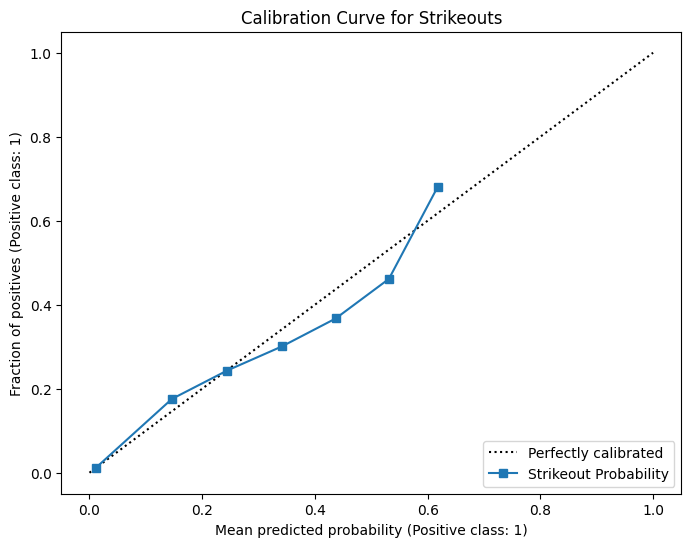

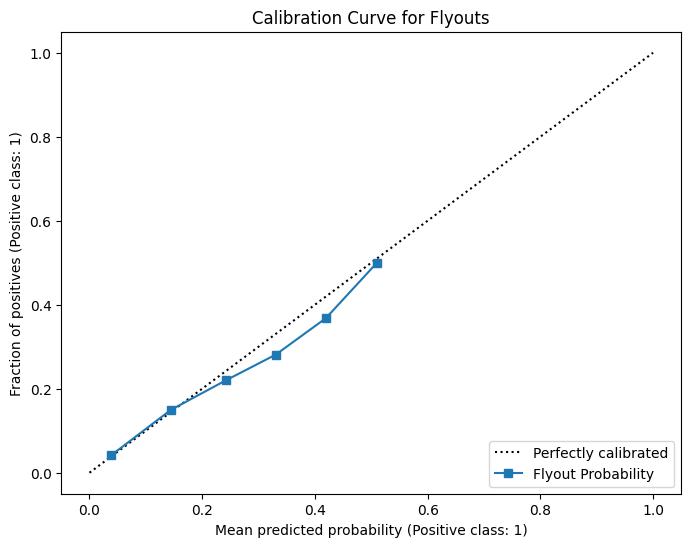

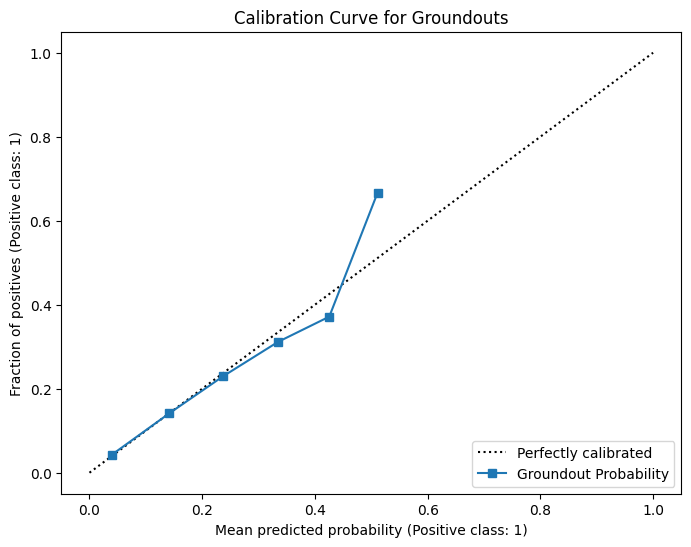

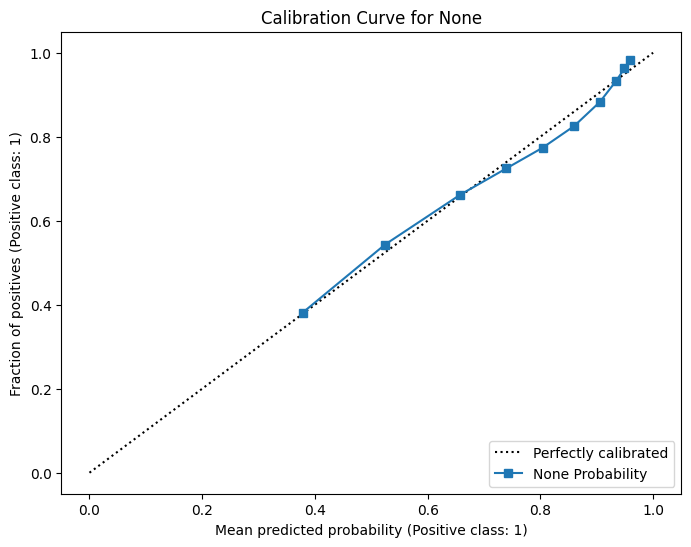

Highest P(SO): 66.86%
          P(None)     P(SO)     P(GO)     P(FO)     actual fly_detail
6574949  0.289481  0.668558  0.022241  0.018822  strikeout           
6584083  0.285461  0.652391  0.042733  0.019131  strikeout           
5821344  0.294273  0.641202  0.022258  0.030038  strikeout           
6052758  0.311620  0.636199  0.034126  0.017905  strikeout           
6486972  0.285061  0.630333  0.046324  0.037321    flyball        out
5857236  0.328784  0.628490  0.024296  0.015845       ball           
6128663  0.318913  0.628221  0.031042  0.021174  strikeout           
6234196  0.302736  0.621893  0.037334  0.033379  strikeout           
6429777  0.322832  0.620530  0.033994  0.020879       ball           
6573141  0.307693  0.619541  0.029889  0.036172  strikeout           
6045593  0.327248  0.614937  0.035740  0.021133       ball           
6140073  0.308945  0.612106  0.049073  0.025280  strikeout           
6166999  0.330714  0.611810  0.025312  0.028428       ball          

In [12]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

is_fly = test_labels['bb_type'].isin(['fly_ball', 'line_drive', 'popup'])
is_hhfb = is_fly & model_data.loc[X1_test.index, 'is_hard_hit']
is_regular_fb = is_fly & ~model_data.loc[X1_test.index, 'is_hard_hit']

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y_true == 1).astype(int),
    prob_df['P(SO)'],
    n_bins=10,
    ax=ax,
    name='Strikeout Probability'
)
plt.title('Calibration Curve for Strikeouts')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    is_regular_fb.astype(int),
    prob_df['P(FO)'],
    n_bins=10,
    ax=ax,
    # strategy='quantile',
    name='Flyout Probability'
)
plt.title('Calibration Curve for Flyouts')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y_true == 2).astype(int),
    prob_df['P(GO)'],
    n_bins=10,
    ax=ax,
    name='Groundout Probability'
)
plt.title('Calibration Curve for Groundouts')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y_true == 0).astype(int),
    prob_df['P(None)'],
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='None Probability'
)
plt.title('Calibration Curve for None')
plt.show()

results = X1_test.copy()
results[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'P(HHFB)']] = prob_df[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'P(HHFB)']]
test_labels = model_data.loc[X1_test.index]
conditions = [
    (test_labels['outcome'] == 'strikeout'),

    (test_labels['bb_type'] == 'ground_ball') | 
    ((test_labels['outcome'] == 'groundout') & test_labels['bb_type'].isna()),

    # hard-hit fly balls
    (
        test_labels['bb_type'].isin(['fly_ball', 'line_drive', 'popup']) &
        model_data.loc[X1_test.index, 'is_hard_hit']
    ),

    # regular fly balls (non-hard-hit)
    (
        test_labels['bb_type'].isin(['fly_ball', 'line_drive', 'popup'])
    ) & ~model_data.loc[X1_test.index, 'is_hard_hit'] |
    (
        (test_labels['outcome'].isin(['flyout', 'hit'])) &
        test_labels['bb_type'].isna()
    )
]

choices = ['strikeout', 'groundball', 'hard_hit_flyball', 'flyball']
results['actual'] = np.select(conditions, choices, default=test_labels['outcome'])

is_fly = (
    test_labels['bb_type'].isin(['fly_ball', 'line_drive', 'popup'])
    | test_labels['outcome'].isin(['flyout'])
)
results['fly_detail'] = np.where(
    is_fly,
    np.where(test_labels['outcome'] == 'hit', 'hit', 'out'),
    ''
)

top_so = results.sort_values('P(SO)', ascending=False).head(50)
print(f"Highest P(SO): {top_so['P(SO)'].iloc[0]:.2%}")
print(top_so[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'actual', 'fly_detail']])

top_fo = results.sort_values('P(FO)', ascending=False).head(50)
print(f"Highest P(FO): {top_fo['P(FO)'].iloc[0]:.2%}")
print(top_fo[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'actual', 'fly_detail']])

top_hhfb = results.sort_values('P(HHFB)', ascending=False).head(50)
print(f"Highest P(HHFB): {top_hhfb['P(HHFB)'].iloc[0]:.2%}")
print(top_hhfb[['P(HHFB)', 'actual', 'fly_detail']])

top_go = results.sort_values('P(GO)', ascending=False).head(50)
print(f"Highest P(GO): {top_go['P(GO)'].iloc[0]:.2%}")
print(top_go[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'actual', 'fly_detail']])

top_none = results.sort_values('P(None)', ascending=False).head(50)
print(f"Highest P(None): {top_none['P(None)'].iloc[0]:.2%}")
print(top_none[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'actual', 'fly_detail']])

lowest_none = results.sort_values('P(None)', ascending=True).head(50)
print(f"Lowest P(None): {lowest_none['P(None)'].iloc[0]:.2%}")
print(lowest_none[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'actual', 'fly_detail']])